In [ ]:
import torch
print(torch.cuda.is_available())

True


In [ ]:
!nvidia-smi

Mon Mar  9 15:29:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install transformers datasets accelerate

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn
!pip install torch torchvision torchaudio
!pip install transformers datasets
!pip install nltk
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 130.7 MB/s eta 0:00:00


In [ ]:
!pip uninstall numpy -y
!pip install numpy==1.26.4

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-p

In [ ]:
import pandas as pd
import numpy as np
import torch
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

from datasets import load_dataset

In [ ]:
!pip install filelock==3.13.1

  Attempting uninstall: filelock
    Found existing installation: filelock 3.24.3
    Uninstalling filelock-3.24.3:
      Successfully uninstalled filelock-3.24.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.0 requires filelock>=3.15, but you have filelock 3.13.1 which is incompatible.
pytensor 2.38.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.


In [ ]:
from datasets import load_dataset

dataset = load_dataset("zeroshot/twitter-financial-news-sentiment")

train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()

print(train_df.head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

sent_train.csv: 0.00B [00:00, ?B/s]

sent_valid.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/9543 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2388 [00:00<?, ? examples/s]

                                                text  label
0  $BYND - JPMorgan reels in expectations on Beyo...      0
1  $CCL $RCL - Nomura points to bookings weakness...      0
2  $CX - Cemex cut at Credit Suisse, J.P. Morgan ...      0
3  $ESS: BTIG Research cuts to Neutral https://t....      0
4  $FNKO - Funko slides after Piper Jaffray PT cu...      0


In [ ]:
print("Train size:", train_df.shape)
print("Validation size:", val_df.shape)

print(train_df["label"].value_counts())

Train size: (9543, 2)
Validation size: (2388, 2)
label
2    6178
1    1923
0    1442
Name: count, dtype: int64


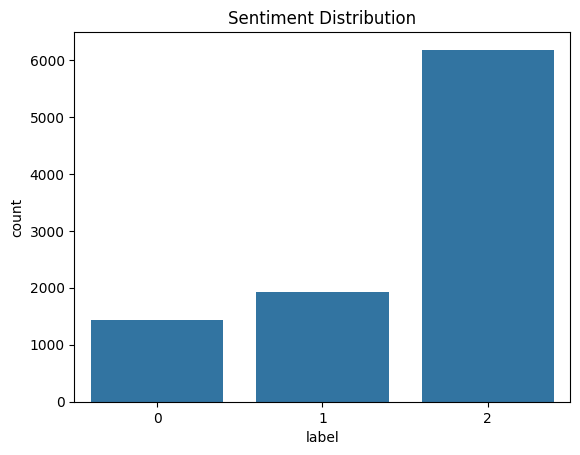

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=train_df["label"])
plt.title("Sentiment Distribution")
plt.show()

In [ ]:
import re

def clean_text(text):

    text = re.sub(r"http\S+", "", text)   # remove URLs
    text = re.sub(r"@\w+", "", text)      # remove mentions
    text = re.sub(r"#", "", text)         # remove hashtags
    text = re.sub(r"\s+", " ", text)      # remove extra spaces

    return text.strip()

In [ ]:
train_df["text"] = train_df["text"].apply(clean_text)
val_df["text"] = val_df["text"].apply(clean_text)

train_df.head()

,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral,0
4,$FNKO - Funko slides after Piper Jaffray PT cut,0


In [ ]:
!pip install keras-preprocessing

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.5 MB/s eta 0:00:00


In [ ]:
from keras_preprocessing.text import Tokenizer
from keras_preprocessing.sequence import pad_sequences

In [ ]:
from keras_preprocessing.text import Tokenizer
from keras_preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=20000)

tokenizer.fit_on_texts(train_df["text"])

In [ ]:
X_train = tokenizer.texts_to_sequences(train_df["text"])
X_val = tokenizer.texts_to_sequences(val_df["text"])

max_len = 50

X_train = pad_sequences(X_train, maxlen=max_len)
X_val = pad_sequences(X_val, maxlen=max_len)

In [ ]:
y_train = train_df["label"].values
y_val = val_df["label"].values

In [ ]:
import torch

X_train_tensor = torch.tensor(X_train, dtype=torch.long)
X_val_tensor = torch.tensor(X_val, dtype=torch.long)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

In [ ]:
import torch.nn as nn

class LSTMModel(nn.Module):

    def __init__(self, vocab_size, embed_dim, hidden_dim):

        super(LSTMModel, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(hidden_dim, 3)

    def forward(self, x):

        x = self.embedding(x)

        output, (hidden, cell) = self.lstm(x)

        hidden = self.dropout(hidden[-1])

        out = self.fc(hidden)

        return out

In [ ]:
vocab_size = 20000
embed_dim = 128
hidden_dim = 64

model = LSTMModel(vocab_size, embed_dim, hidden_dim)

print(model)

LSTMModel(
  (embedding): Embedding(20000, 128)
  (lstm): LSTM(128, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

batch_size = 64

train_loader = DataLoader(train_dataset,
                          batch_size=batch_size,
                          shuffle=True)

val_loader = DataLoader(val_dataset,
                        batch_size=batch_size)

In [ ]:
epochs = 10

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("Epoch:", epoch+1, "Loss:", total_loss)

Epoch: 1 Loss: 130.85399621725082
Epoch: 2 Loss: 103.75405570864677
Epoch: 3 Loss: 82.4013130813837
Epoch: 4 Loss: 62.913714945316315
Epoch: 5 Loss: 45.63441102206707
Epoch: 6 Loss: 31.842333510518074
Epoch: 7 Loss: 21.70895267650485
Epoch: 8 Loss: 14.258862737566233
Epoch: 9 Loss: 11.323578648269176
Epoch: 10 Loss: 8.024920742027462


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

model.eval()

predictions = []
true_labels = []

with torch.no_grad():

    for X_batch, y_batch in val_loader:

        outputs = model(X_batch)

        preds = torch.argmax(outputs, dim=1)

        predictions.extend(preds.numpy())
        true_labels.extend(y_batch.numpy())

In [ ]:
from sklearn.metrics import classification_report

accuracy = accuracy_score(true_labels, predictions)

f1 = f1_score(true_labels, predictions, average="macro")

print("Accuracy:", accuracy)
print("Macro F1 Score:", f1)

print(classification_report(true_labels, predictions))

Accuracy: 0.7613065326633166
Macro F1 Score: 0.6836718662608016
              precision    recall  f1-score   support

           0       0.51      0.60      0.55       347
           1       0.63      0.67      0.65       475
           2       0.88      0.82      0.85      1566

    accuracy                           0.76      2388
   macro avg       0.67      0.70      0.68      2388
weighted avg       0.77      0.76      0.77      2388



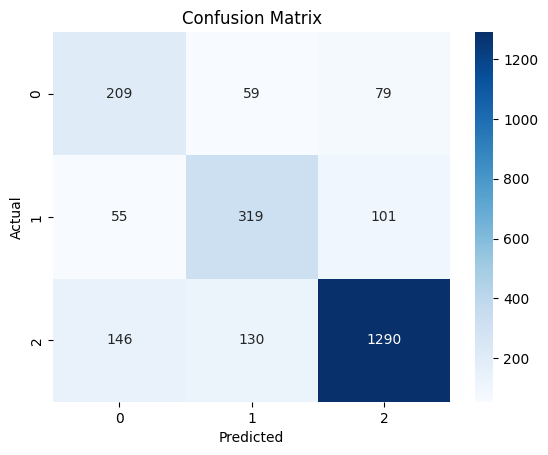

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predictions)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
!pip install torch==2.4.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.0/797.0 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 100.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch
print(torch.__version__)

2.4.1+cu121


In [ ]:
!pip uninstall torch torchvision transformers datasets -y

Found existing installation: torch 2.4.1
Uninstalling torch-2.4.1:
  Successfully uninstalled torch-2.4.1
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0


In [ ]:
!pip install torch==2.4.1 torchvision==0.19.1
!pip install transformers==4.44.2 datasets==2.21.0

  Using cached torch-2.4.1-cp312-cp312-manylinux1_x86_64.whl.metadata (26 kB)
Using cached torch-2.4.1-cp312-cp312-manylinux1_x86_64.whl (797.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 8.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
peft 0.18.1 requires transformers, which is not installed.
sentence-transformers 5.2.3 requires transformers<6.0.0,>=4.41.0, which is not installed.
torchtune 0.6.1 requires datasets, which is not installed.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.4.1 which is incompatible.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.4 MB/s eta 0:00:00
ERROR: Operation cancelled by user
^C


In [ ]:
!pip install transformers==4.44.2 datasets==2.21.0
import torch
import transformers
import datasets

print("Torch version:", torch.__version__)
print("Transformers version:", transformers.__version__)
print("Datasets version:", datasets.__version__)

  Using cached transformers-4.44.2-py3-none-any.whl.metadata (43 kB)
  Using cached datasets-2.21.0-py3-none-any.whl.metadata (21 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 96.6 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.5.0
    Uninstalling huggingface_hub-1.5.0:
      Successfully uninstalled huggingface_hub-1.5.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

Torch version: 2.4.1+cu121
Transformers version: 4.44.2
Datasets version: 2.21.0


In [ ]:
from transformers import Trainer, TrainingArguments

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [ ]:
model_name = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

In [ ]:
def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=64
    )

In [ ]:
from datasets import load_dataset

dataset = load_dataset("zeroshot/twitter-financial-news-sentiment")

In [ ]:
tokenized_dataset = dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/9543 [00:00<?, ? examples/s]

Map:   0%|          | 0/2388 [00:00<?, ? examples/s]

In [ ]:
tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

In [ ]:
!pip install accelerate -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 16.0 MB/s eta 0:00:00
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.12.0
    Uninstalling accelerate-1.12.0:
      Successfully uninstalled accelerate-1.12.0


In [ ]:
!pip install "transformers[torch]"

In [ ]:
from transformers import TrainingArguments, Trainer

In [ ]:
training_args = TrainingArguments(
    output_dir="./bert_results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01
)

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [ ]:
model_name = "ProsusAI/finbert"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [ ]:
from datasets import load_dataset

dataset = load_dataset("zeroshot/twitter-financial-news-sentiment")

In [ ]:
from transformers import AutoTokenizer

model_name = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=64
    )
tokenized_dataset = dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/2388 [00:00<?, ? examples/s]

In [ ]:
tokenized_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
)

In [ ]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss
1,0.560500,0.373613
2,0.299000,0.366745
3,0.188500,0.439696


TrainOutput(global_step=1791, training_loss=0.3175036794043732, metrics={'train_runtime': 541.4281, 'train_samples_per_second': 52.877, 'train_steps_per_second': 3.308, 'total_flos': 941584254516864.0, 'train_loss': 0.3175036794043732, 'epoch': 3.0})

In [ ]:
trainer.evaluate()

{'eval_loss': 0.4396960437297821,
 'eval_runtime': 10.9533,
 'eval_samples_per_second': 218.017,
 'eval_steps_per_second': 27.298,
 'epoch': 3.0}

In [ ]:
predictions = trainer.predict(tokenized_dataset["validation"])

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

preds = predictions.predictions.argmax(-1)
labels = predictions.label_ids

print("Accuracy:", accuracy_score(labels, preds))
print("Macro F1:", f1_score(labels, preds, average="macro"))

Accuracy: 0.8814907872696818
Macro F1: 0.8429219507301896


In [ ]:
predictions = trainer.predict(tokenized_dataset["validation"])

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

preds = predictions.predictions.argmax(-1)
labels = predictions.label_ids

accuracy = accuracy_score(labels, preds)
f1 = f1_score(labels, preds, average="macro")

print("Accuracy:", accuracy)
print("Macro F1 Score:", f1)

Accuracy: 0.8814907872696818
Macro F1 Score: 0.8429219507301896


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(labels, preds))

              precision    recall  f1-score   support

           0       0.79      0.79      0.79       347
           1       0.83      0.81      0.82       475
           2       0.92      0.92      0.92      1566

    accuracy                           0.88      2388
   macro avg       0.84      0.84      0.84      2388
weighted avg       0.88      0.88      0.88      2388



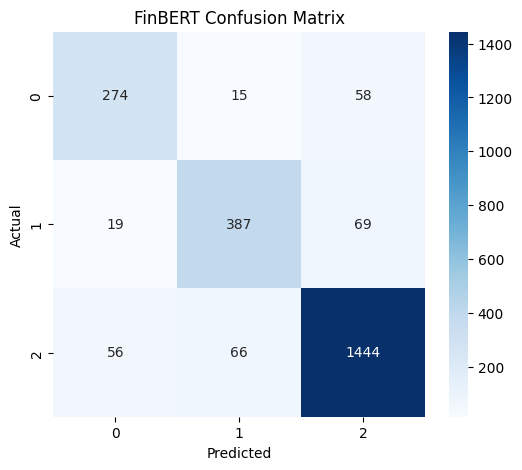

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("FinBERT Confusion Matrix")

plt.show()

In [ ]:
model.save_pretrained("finbert_model")
tokenizer.save_pretrained("finbert_model")

('finbert_model/tokenizer_config.json',
 'finbert_model/special_tokens_map.json',
 'finbert_model/vocab.txt',
 'finbert_model/added_tokens.json',
 'finbert_model/tokenizer.json')

In [ ]:
from google.colab import files
import shutil

shutil.make_archive("finbert_model", 'zip', "finbert_model")
files.download("finbert_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>